## Задание Байессовская регрессия

Реализуйте с нуля байесовскую линейную регрессию. Используйте для обучения модели датасет 
Сравните (по метрикам MAE, MSE, RMSE, R2, MAPE и визуальный анализ предсказаний моделей) свою реализацию с обычной линейной регрессией, lasso-регрессией, Ridge-регрессией и реализацией байесовской регрессии из sklearn (дополнительно можно рассмотреть дрругие библиотеки). 

Ответьте на вопрос, как байесовский подход помогает оценивать неопределённость и бороться с переобучением.

In [1]:
import numpy

import sklearn.base

class BayesianLinearRegression(sklearn.base.RegressorMixin):
    def __init__(
        self, alpha: float = 1.0, beta: float = 50.0, n_iter: int = 200,
    ):
        self.alpha = alpha
        self.beta = beta
        self.n_iter = n_iter

    def fit(self, X: numpy.ndarray, y: numpy.ndarray):
        self.intercept = y.mean()
        y = y - self.intercept
        XtX, Xty = X.T @ X, X.T @ y

        def posterior(alpha: float, beta: float):
            A = alpha * numpy.eye(X.shape[1]) + beta * XtX
            invA = numpy.linalg.inv(A)
            return beta * (invA @ Xty), invA

        self.coef, S = posterior(self.alpha, self.beta)
        for _ in range(self.n_iter):
            gamma = X.shape[1] - self.alpha * numpy.trace(S)
            resid = y - X @ self.coef

            self.alpha = gamma / (self.coef @ self.coef)
            self.beta = (X.shape[0] - gamma) / (resid @ resid)
            self.coef, S = posterior(self.alpha, self.beta)

        return self

    def predict(self, X: numpy.ndarray):
        return X @ self.coef + self.intercept

In [2]:
import sklearn.metrics
import sklearn.datasets
import sklearn.preprocessing
import sklearn.model_selection

def estimate_quality(y_true: numpy.ndarray, y_pred: numpy.ndarray) -> dict:
    return {
        "MAE": sklearn.metrics.mean_absolute_error(y_true, y_pred),
        "MSE": sklearn.metrics.mean_squared_error(y_true, y_pred),
        "RMSE": sklearn.metrics.root_mean_squared_error(y_true, y_pred),
        "R2": sklearn.metrics.r2_score(y_true, y_pred),
        "MAPE": 100 * sklearn.metrics.mean_absolute_percentage_error(y_true, y_pred)
    }

X, y = sklearn.datasets.load_diabetes(return_X_y=True)
X_train, X_test, y_train, y_test =sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

ss = sklearn.preprocessing.StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

,model,MAE,MSE,RMSE,R2,MAPE
0,LinearRegression,43.483504,2868.549703,53.558843,0.527919,38.919947
1,Lasso,43.515660,2872.790852,53.598422,0.527221,38.946973
2,Ridge,43.483737,2868.577712,53.559105,0.527915,38.919754
3,BayesianRidge,43.674444,2891.680008,53.774343,0.524113,39.109771
4,BayesianLinearRegression,43.674444,2891.680004,53.774343,0.524113,39.109771


,model,MAE,MSE,RMSE,R2,MAPE
0,LinearRegression,42.794095,2900.193628,53.853446,0.452603,37.499826
1,Lasso,42.805234,2884.624289,53.708698,0.455541,37.414255
2,Ridge,42.796235,2899.054556,53.842869,0.452818,37.492795
3,BayesianRidge,42.870397,2871.943111,53.590513,0.457935,37.388013
4,BayesianLinearRegression,42.870397,2871.943115,53.590513,0.457935,37.388013


,model,MAE,MSE,RMSE,R2,MAPE
0,LinearRegression,0.689409,-31.643926,-0.294602,0.075317,1.420121
1,Lasso,0.710426,-11.833437,-0.110276,0.071680,1.532718
2,Ridge,0.687502,-30.476844,-0.283764,0.075097,1.426959
3,BayesianRidge,0.804047,19.736896,0.183830,0.066178,1.721758
4,BayesianLinearRegression,0.804047,19.736890,0.183830,0.066178,1.721758


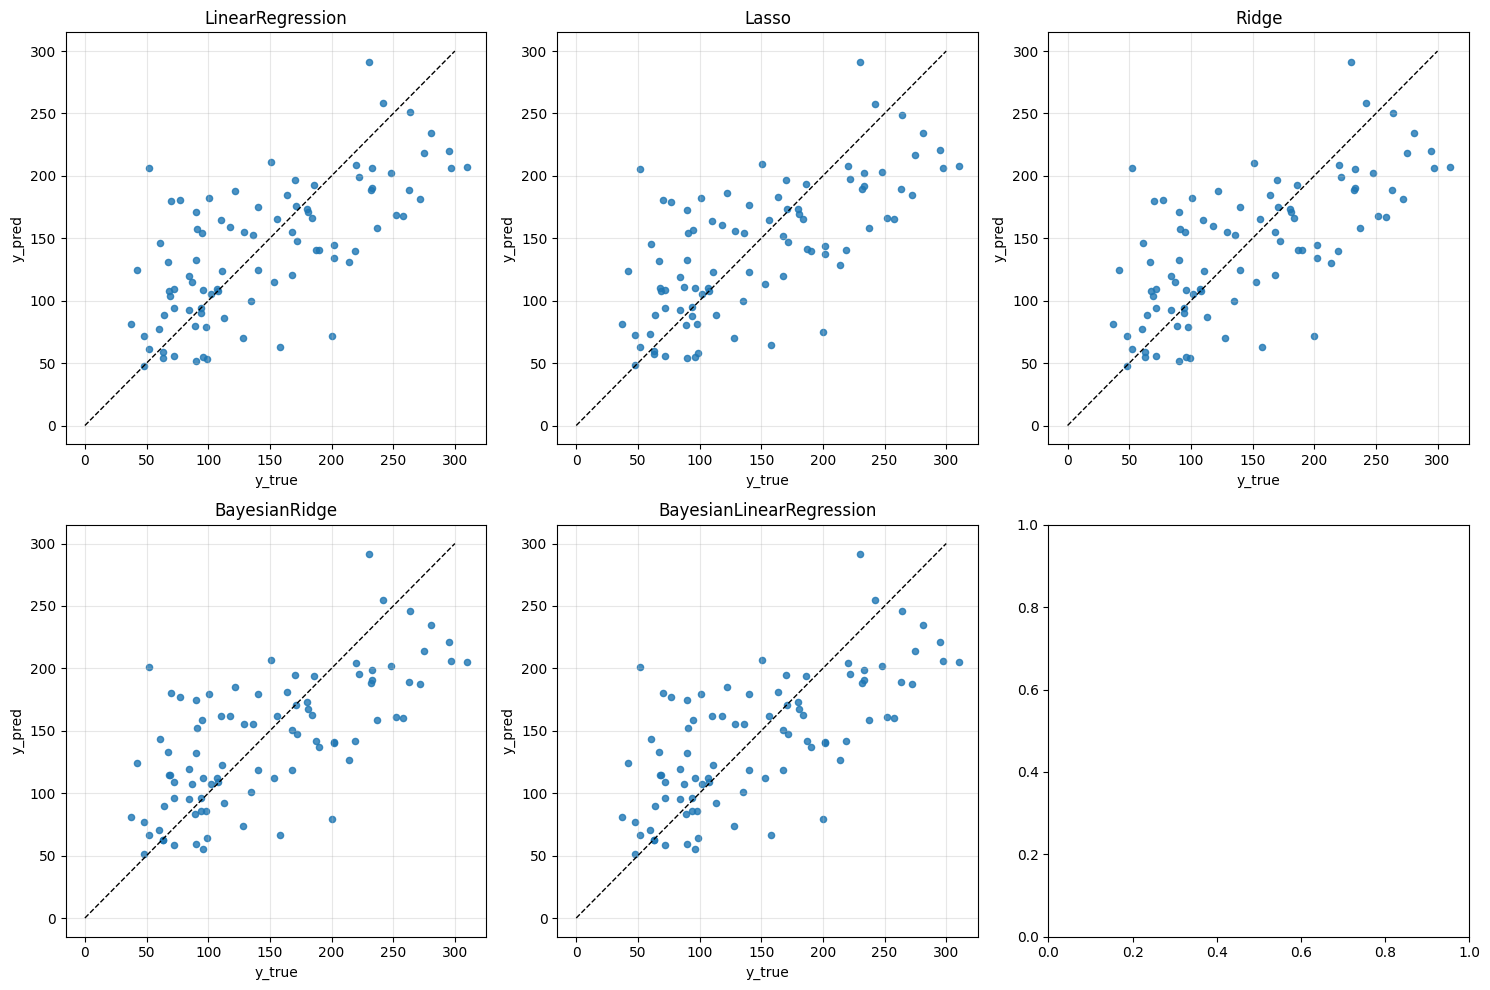

In [3]:
import pandas
import sklearn.linear_model
import matplotlib.pyplot as plt

models = [
    sklearn.linear_model.LinearRegression(),
    sklearn.linear_model.Lasso(alpha=0.1, random_state=42),
    sklearn.linear_model.Ridge(alpha=0.1, random_state=42),
    sklearn.linear_model.BayesianRidge(),
    BayesianLinearRegression()
]

train_scores, test_scores = [], []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, model in zip(axes.flat, models):
    model = model.fit(X_train, y_train)
    model_name = type(model).__name__

    y_pred_train = model.predict(X_train)
    train_scores.append({"model": model_name, **estimate_quality(y_train, y_pred_train)})

    y_pred_test = model.predict(X_test)
    test_scores.append({"model": model_name, **estimate_quality(y_test, y_pred_test)})

    ax.scatter(y_test, y_pred_test, s=20, alpha=0.8)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("y_true")
    ax.set_ylabel("y_pred")
    ax.set_title(model_name)
    ax.plot([0, 300], [0, 300], 'k--', lw=1)
    
train_scores = pandas.DataFrame(train_scores)
test_scores = pandas.DataFrame(test_scores)
display(train_scores)
display(test_scores)

diff = train_scores.copy()
diff[["MAE", "MSE", "RMSE", "R2", "MAPE"]] -= test_scores[["MAE", "MSE", "RMSE", "R2", "MAPE"]]
display(diff)
fig.tight_layout()

Реализованная регрессия с точностью совпадает с реализацией из sklearn. 

> Как байесовский подход помогает оценивать неопределённость и бороться с переобучением.

При построение моделей на основе байесовского подхода веса моделей рассматриваются как случайные величины с некоторым априорным распределением (например, нормальным). В процессе обучения модель получает наблюдаемые данные, которые с помощью формулы Байеса позволяют вычислить апостериорные вероятности весов и использовать их для формирования предсказаний на новых объектах.

Байесовская линейная регрессия фактически представляет собой обычную линейную модель, но обученную на основе наблюдаемых вероятностных распределений данных, а не путём оптимизации некоторого функционала. Таким образом, модель формирует не только одну точку прогноза, а целое вероятностное распределение, которое может быть отдельно исследовано, в том числе с точки зрения доверительных интервалов. Именно эта особенность и позволяет уникальным образом оценивать неопределённость модели.

Борьба с переобучением получается естественным образом через априорное распределение, параметры которого фактически и отвечают за степень регуляризации. Более того, Байесовский подход позволяет динамически корректировать эти параметры (т.н. "эмпирический Байес"), что является фактически стандартной реализацией таких моделей. Таким образом, процесс обучения естественным образом интегрирует регуляризацию в модель, что зачастую улучшает обобщающую способность и снижает переобучение. Более того, эффект наблюдается даже на "искусственных" данных, рассмотренных выше: Байесовская линейная регрессия показывает наилучшее качество предсказаний на тестовой выборке из всех рассмотренных моделей при том, что переобучения фактически нет: ошибка на тренировочной выборке даже выше, чем на тестовой.